In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
import pandas as pd
import numpy as np
import sqlite3

from sklearn.preprocessing import StandardScaler

In [5]:
conn = sqlite3.connect(
    "../../data/warehouse/saas.db"
)

In [6]:
df = pd.read_sql_query(
    "SELECT * FROM customer_360",
    conn
)

df.head()

,user_id,country,industry,company_size,plan_type,monthly_revenue,is_churned,total_usage_events,avg_session_duration,total_tickets,avg_resolution_time,avg_satisfaction,total_campaign_engagements,email_open_rate,click_rate
0,1,USA,SaaS,Enterprise,Pro,150,0,54,33.648148,0,NaN,NaN,15,0.666667,0.533333
1,2,India,Healthcare,Small,Basic,50,1,7,4.714286,3,69.333333,4.333333,2,0.000000,0.500000
2,3,UK,SaaS,Enterprise,Basic,50,1,13,5.230769,6,60.833333,3.666667,1,1.000000,0.000000
3,4,Canada,SaaS,Enterprise,Basic,50,0,99,34.747475,0,NaN,NaN,8,0.750000,0.750000
4,5,Germany,SaaS,Small,Basic,50,0,117,33.512821,4,16.250000,7.250000,11,0.545455,0.545455


In [7]:
df["customer_health_score"] = (
    df["avg_session_duration"] * 0.4
    + df["email_open_rate"] * 30
    + df["click_rate"] * 30
    - df["total_tickets"] * 2
)

In [8]:
df["engagement_score"] = (
    df["total_usage_events"] * 0.5
    + df["avg_session_duration"] * 2
)

df["support_burden_score"] = (
    df["total_tickets"] * 3
    + (
        10 - df["avg_satisfaction"].fillna(10)
    ) * 2
)

df["marketing_engagement_score"] = (
    df["email_open_rate"] * 50
    + df["click_rate"] * 50
)

df["frequency_score"] = (
    df["total_usage_events"]
)

df["monetary_score"] = (
    df["monthly_revenue"]
)

df["recency_score"] = np.random.randint(
    1,
    30,
    size=len(df)
)

In [9]:
df["avg_resolution_time"] = df[
    "avg_resolution_time"
].fillna(0)

df["avg_satisfaction"] = df[
    "avg_satisfaction"
].fillna(10)

In [10]:
df_encoded = pd.get_dummies(
    df,
    columns=[
        "country",
        "industry",
        "company_size",
        "plan_type"
    ],
    drop_first=True
)

In [11]:
scaler = StandardScaler()

feature_cols = df_encoded.drop(
    columns=["is_churned"]
).columns

df_encoded[feature_cols] = scaler.fit_transform(
    df_encoded[feature_cols]
)

In [12]:
X = df_encoded.drop(
    columns=["is_churned"]
)

y = df_encoded["is_churned"]

In [13]:
X.shape

(5000, 29)

In [15]:
y.shape

(5000,)

In [16]:
from sklearn.model_selection import train_test_split

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [18]:
X_train.shape

(4000, 29)

In [19]:
X_test.shape

(1000, 29)

In [20]:
from sklearn.linear_model import LogisticRegression

In [21]:
log_model = LogisticRegression()

In [22]:
log_model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [23]:
y_pred_log = log_model.predict(X_test)

In [24]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [25]:
print(
    "Accuracy:",
    accuracy_score(y_test, y_pred_log)
)

print(
    "Precision:",
    precision_score(y_test, y_pred_log)
)

print(
    "Recall:",
    recall_score(y_test, y_pred_log)
)

print(
    "F1 Score:",
    f1_score(y_test, y_pred_log)
)

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0


In [26]:
from sklearn.metrics import confusion_matrix

In [27]:
cm = confusion_matrix(
    y_test,
    y_pred_log
)

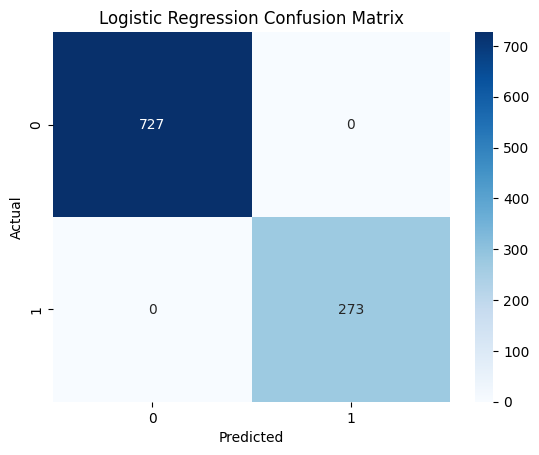

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(
    "Logistic Regression Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [29]:
from sklearn.metrics import roc_auc_score

In [30]:
y_prob_log = log_model.predict_proba(
    X_test
)[:,1]

In [31]:
roc_auc = roc_auc_score(
    y_test,
    y_prob_log
)

print("ROC-AUC:", roc_auc)

ROC-AUC: 1.0


In [32]:
from sklearn.tree import DecisionTreeClassifier

In [33]:
tree_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

In [35]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

In [36]:
tree_model.fit(
    X_train,
    y_train
)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [37]:
y_pred_tree = tree_model.predict(
    X_test
)

In [38]:
print(
    "Accuracy:",
    accuracy_score(y_test, y_pred_tree)
)

print(
    "Precision:",
    precision_score(y_test, y_pred_tree)
)

print(
    "Recall:",
    recall_score(y_test, y_pred_tree)
)

print(
    "F1 Score:",
    f1_score(y_test, y_pred_tree)
)

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0


In [39]:
from sklearn.ensemble import RandomForestClassifier

In [40]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [41]:
rf_model.fit(
    X_train,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [42]:
y_pred_rf = rf_model.predict(
    X_test
)

In [43]:
print(
    "Accuracy:",
    accuracy_score(y_test, y_pred_rf)
)

print(
    "Precision:",
    precision_score(y_test, y_pred_rf)
)

print(
    "Recall:",
    recall_score(y_test, y_pred_rf)
)

print(
    "F1 Score:",
    f1_score(y_test, y_pred_rf)
)

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0


In [44]:
y_prob_rf = rf_model.predict_proba(
    X_test
)[:,1]

In [45]:
roc_auc_rf = roc_auc_score(
    y_test,
    y_prob_rf
)

print(
    "Random Forest ROC-AUC:",
    roc_auc_rf
)

Random Forest ROC-AUC: 1.0


In [46]:
importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": rf_model.feature_importances_
})

In [47]:
importance_df = importance_df.sort_values(
    by="importance",
    ascending=False
)

importance_df.head(10)

,feature,importance
6,avg_satisfaction,0.246982
2,total_usage_events,0.151833
3,avg_session_duration,0.136602
11,engagement_score,0.104147
14,frequency_score,0.097943
12,support_burden_score,0.058451
5,avg_resolution_time,0.053222
13,marketing_engagement_score,0.032575
10,customer_health_score,0.031672
7,total_campaign_engagements,0.031110


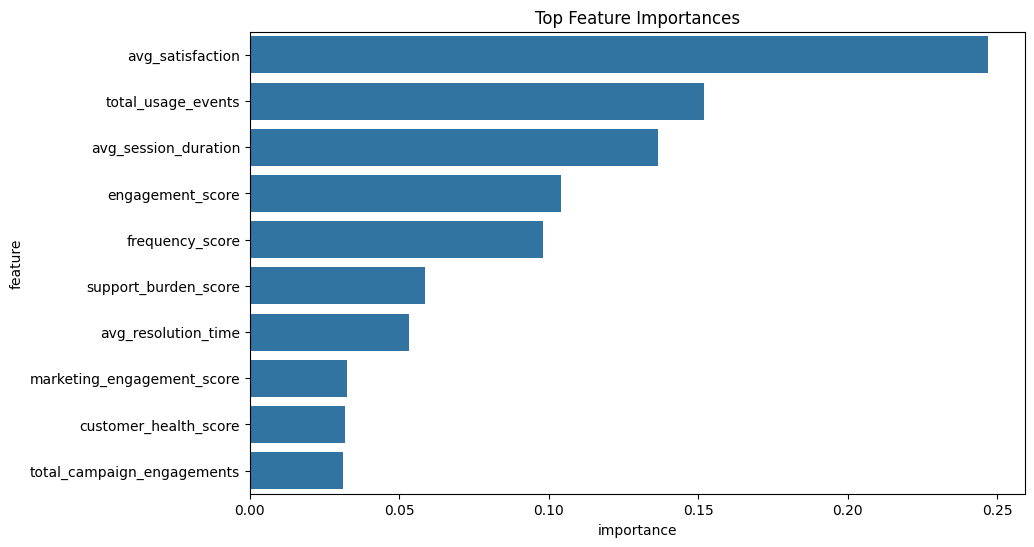

In [48]:
top_features = importance_df.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_features,
    x="importance",
    y="feature"
)

plt.title(
    "Top Feature Importances"
)

plt.show()

In [50]:
y_prob_tree = tree_model.predict_proba(
    X_test
)[:,1]

In [52]:
roc_auc_tree = roc_auc_score(
    y_test,
    y_prob_tree
)

print(
    "Decision Tree ROC-AUC:",
    roc_auc_tree
)

Decision Tree ROC-AUC: 1.0


In [53]:
model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "ROC-AUC": [
        roc_auc,
        roc_auc_tree,
        roc_auc_rf
    ]
})

model_results

,Model,ROC-AUC
0,Logistic Regression,1.0
1,Decision Tree,1.0
2,Random Forest,1.0


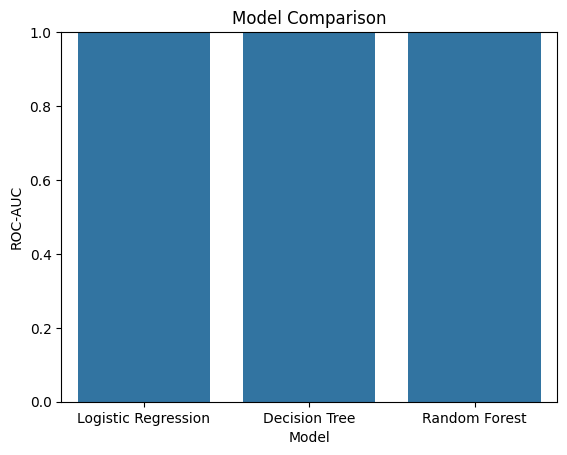

In [54]:
sns.barplot(
    data=model_results,
    x="Model",
    y="ROC-AUC"
)

plt.title("Model Comparison")

plt.ylim(0,1)

plt.show()

In [58]:
pip install xgboost


Note: you may need to restart the kernel to use updated packages.


In [59]:
from xgboost import XGBClassifier

In [60]:
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)

In [61]:
xgb_model.fit(
    X_train,
    y_train
)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [62]:
y_pred_xgb = xgb_model.predict(
    X_test
)

In [63]:
print(
    "Accuracy:",
    accuracy_score(y_test, y_pred_xgb)
)

print(
    "Precision:",
    precision_score(y_test, y_pred_xgb)
)

print(
    "Recall:",
    recall_score(y_test, y_pred_xgb)
)

print(
    "F1 Score:",
    f1_score(y_test, y_pred_xgb)
)

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0


In [64]:
y_prob_xgb = xgb_model.predict_proba(
    X_test
)[:,1]

roc_auc_xgb = roc_auc_score(
    y_test,
    y_prob_xgb
)

print(
    "XGBoost ROC-AUC:",
    roc_auc_xgb
)

XGBoost ROC-AUC: 1.0


In [65]:
model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],
    "ROC-AUC": [
        roc_auc,
        roc_auc_tree,
        roc_auc_rf,
        roc_auc_xgb
    ]
})

model_results

,Model,ROC-AUC
0,Logistic Regression,1.0
1,Decision Tree,1.0
2,Random Forest,1.0
3,XGBoost,1.0


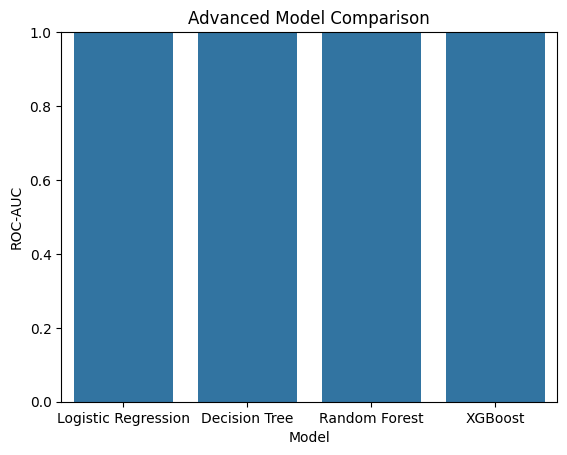

In [66]:
sns.barplot(
    data=model_results,
    x="Model",
    y="ROC-AUC"
)

plt.title("Advanced Model Comparison")

plt.ylim(0,1)

plt.show()

In [67]:
xgb_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": xgb_model.feature_importances_
})

In [68]:
xgb_importance = xgb_importance.sort_values(
    by="importance",
    ascending=False
)

xgb_importance.head(10)

,feature,importance
2,total_usage_events,0.996987
12,support_burden_score,0.003013
0,user_id,0.000000
3,avg_session_duration,0.000000
1,monthly_revenue,0.000000
4,total_tickets,0.000000
5,avg_resolution_time,0.000000
7,total_campaign_engagements,0.000000
6,avg_satisfaction,0.000000
8,email_open_rate,0.000000


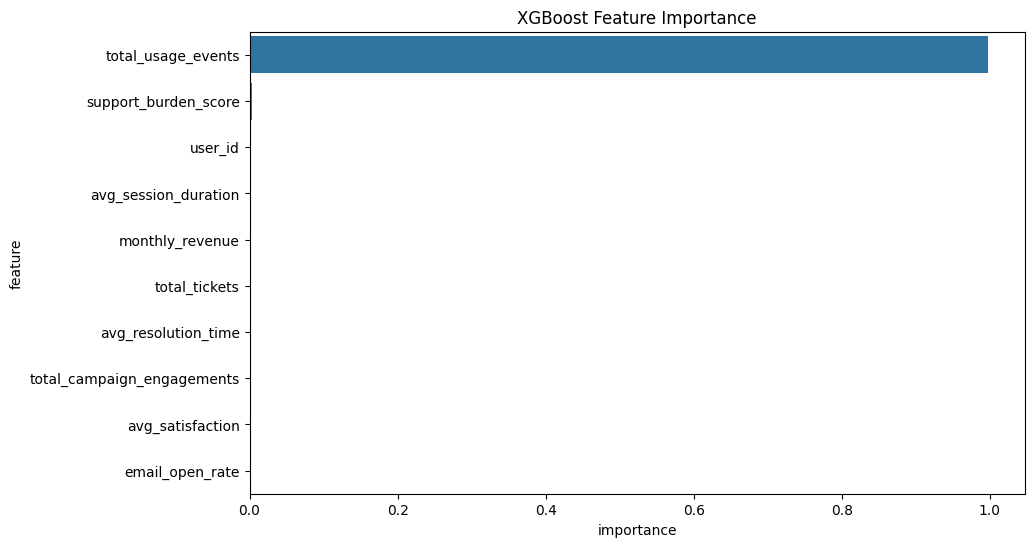

In [69]:
top_xgb = xgb_importance.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_xgb,
    x="importance",
    y="feature"
)

plt.title(
    "XGBoost Feature Importance"
)

plt.show()

In [70]:
pip install shap 

  Using cached shap-0.51.0-cp311-cp311-win_amd64.whl.metadata (26 kB)
  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
  Using cached numba-0.65.1-cp311-cp311-win_amd64.whl.metadata (2.8 kB)
  Using cached llvmlite-0.47.0-cp311-cp311-win_amd64.whl.metadata (4.9 kB)
  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
Using cached shap-0.51.0-cp311-cp311-win_amd64.whl (554 kB)
Using cached slicer-0.0.8-py3-none-any.whl (15 kB)
Using cached tqdm-4.67.3-py3-none-any.whl (78 kB)
Using cached cloudpickle-3.1.2-py3-none-any.whl (22 kB)
Using cached llvmlite-0.47.0-cp311-cp311-win_amd64.whl (38.1 MB)
Using cached numba-0.65.1-cp311-cp311-win_amd64.whl (2.7 MB)

   ---------------------------------------- 0/6 [tqdm]
   ---------------------------------------- 0/6 [tqdm]
   ------ --------------------------------- 1/6 [slicer]
   ------------- -------------------------- 2/6 [llvmlite]
   ------------- ----

In [71]:
import shap

In [72]:
explainer = shap.Explainer(
    xgb_model
)

In [73]:
shap_values = explainer(X_test)

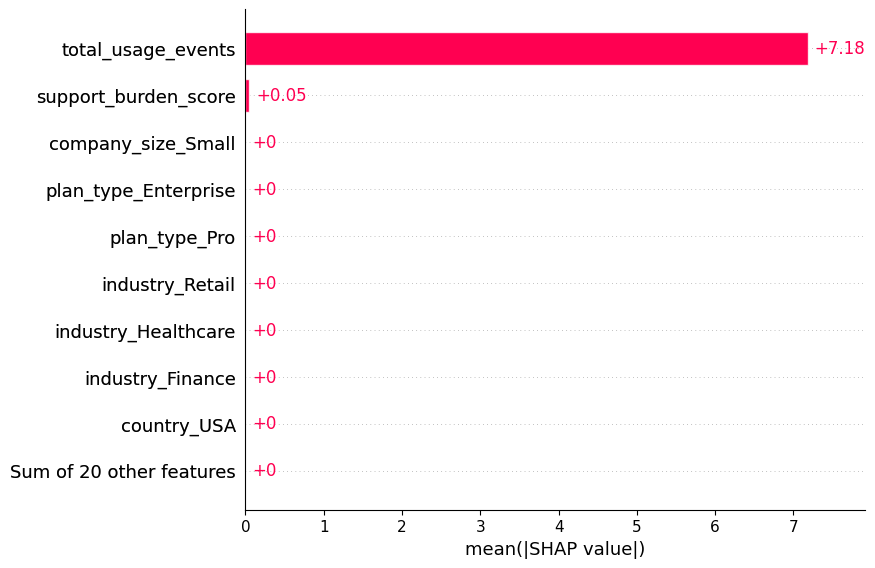

In [74]:
shap.plots.bar(shap_values)

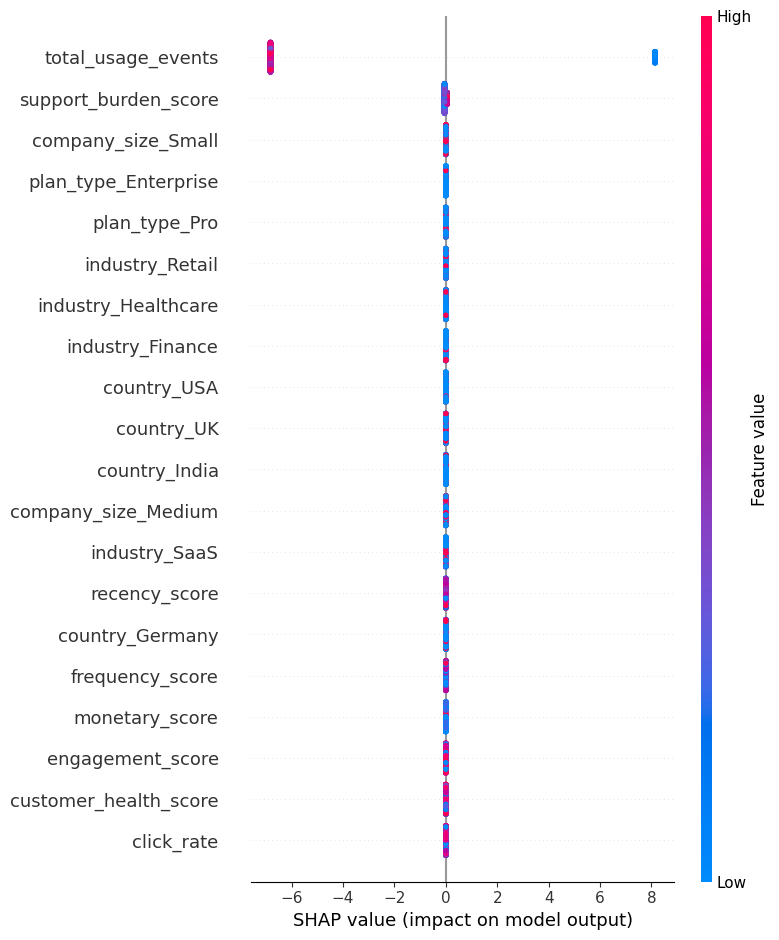

In [75]:
shap.summary_plot(
    shap_values,
    X_test
)

In [76]:
customer_index = 0

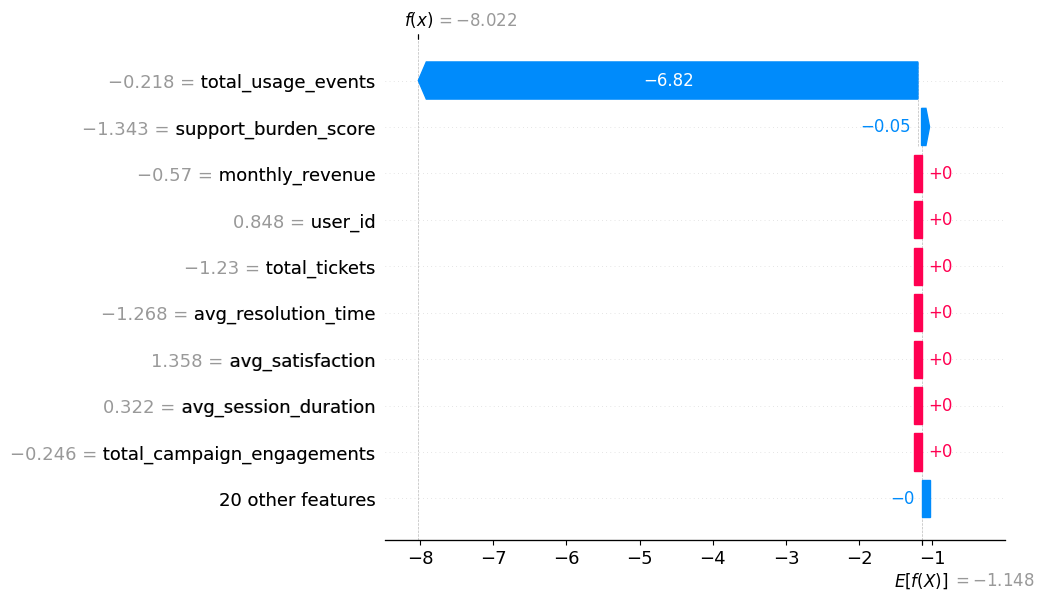

In [77]:
shap.plots.waterfall(
    shap_values[customer_index]
)